# The lab key, run end to end

**TRAINER ONLY.** Week 1, Friday. The data is `v3-lab`, **proposed for client zero v2.3** and
not yet locked, so a number here can still move when the lock lands; rerun this notebook then.

Kavya's terms for the day: "Before anything goes to Meera, rebuild the week from a raw export
with no assistant and no notes. Then say it to me the way you will say it to her."

This notebook is the run a careful analyst makes in about ninety minutes, with each trap a
hurried run falls into computed beside it, exactly, so a TA can recognise a wrong number on a
learner's screen from across the room. Every figure in the lab key and the day sheet comes from
a printed cell below.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import random
import statistics

rows = kit.load_csv("C2_W01_D05_lab_orders_STUDENT.csv")
control = {c["quarter"]: c for c in kit.load_csv("C2_W01_D05_lab_control_STUDENT.csv")}
print(f"{len(rows)} rows read; control totals for {sorted(control)}")
print(rows[0])

207 rows read; control totals for ['Q1', 'Q2']
{'order_id': 'KR-07001', 'customer_id': 'C-7024', 'segment': 'Retail-Core', 'channel': 'app', 'city': 'Bengaluru', 'order_date': '2026-04-02', 'quarter': 'Q1', 'amount': '1370'}


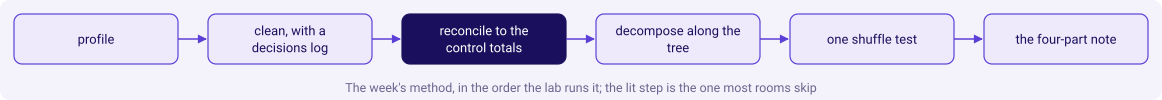

In [2]:
kit.flow(["profile", "clean, with a decisions log", "reconcile to the control totals",
          "decompose along the tree", "one shuffle test", "the four-part note"], lit=2,
         title="The week's method, in the order the lab runs it; the lit step is the one most rooms skip")

## 1. Profile before touching anything

Three counts per field: present, convertible where a number is expected, distinct. The finding
of the profile is every place where a count disagrees with what the field should hold.

In [3]:
def profile(records, field, numeric=False):
    present = [r[field] for r in records if r.get(field, "") != ""]
    convertible = None
    if numeric:
        convertible = 0
        for v in present:
            try:
                int(v)
                convertible += 1
            except ValueError:
                pass
    return len(present), convertible, len(set(present))


fields = list(rows[0])
prof = {f: profile(rows, f, numeric=(f == "amount")) for f in fields}
kit.table(["field", "present", "convertible", "distinct"],
          [(f, p, "" if c is None else c, d) for f, (p, c, d) in prof.items()],
          caption=f"The profile of {len(rows)} rows, before any decision")

field,present,convertible,distinct
order_id,207,,197
customer_id,207,,67
segment,206,,4
channel,207,,3
city,207,,5
order_date,207,,118
quarter,207,,2
amount,207,206,145


In [4]:
ids = [r["order_id"] for r in rows]
kit.check("207 rows carry 197 distinct order ids, so ten rows repeat an id",
          len(rows) == 207 and len(set(ids)) == 197, f"{len(rows)} rows, {len(set(ids))} ids")
kit.check("one amount will not convert and one segment is empty",
          prof["amount"][1] == 206 and prof["segment"][0] == 206)

**The first trap: the typical order.** A hurried profile reports the mean order as the typical
one. The median is the honest answer, because ten corporate orders sit above Rs 7 lakh while
every consumer order sits under Rs 4,000.

In [5]:
amounts_all = sorted(int(r["amount"]) for r in rows if r["amount"].isdigit())
kit.table(["measure", "on the rows that convert, duplicates still in"],
          [("mean order", kit.rupees(statistics.mean(amounts_all))),
           ("median order", kit.rupees(statistics.median(amounts_all)))],
          caption="The mean is the wrong typical order by a factor of about 25")

measure,"on the rows that convert, duplicates still in"
mean order,"Rs 52,057"
median order,"Rs 2,110"


## 2. Clean, with a reason written for every decision

Three decisions, each logged with its row count as it is made. The identity rule is the order
id: two rows with one id are one order. The corporate amount written with Indian digit grouping
is a real order stored as text, so it is converted and flagged, never set to zero. The empty
segment is restored from the same customer's other orders, flagged, because every one of that
customer's other orders carries one segment.

In [6]:
log, clean, rejected, seen, first_raw = [], [], [], {}, {}
customer_segment = {}
for r in rows:
    if r["segment"]:
        customer_segment.setdefault(r["customer_id"], set()).add(r["segment"])

for r in rows:
    r = dict(r)
    first_raw.setdefault(r["order_id"], dict(r))
    if r["order_id"] in seen:
        same = first_raw[r["order_id"]] == r
        rejected.append(r)
        log.append({"order_id": r["order_id"], "decision": "drop",
                    "reason": "second row of an order already kept" + ("" if same else ", fields differ")})
        continue
    if not r["amount"].isdigit():
        digits = r["amount"].replace(",", "")
        log.append({"order_id": r["order_id"], "decision": "convert and flag",
                    "reason": f"amount stored as text {r['amount']!r}, read as {digits}"})
        r["amount"] = digits
    if r["segment"] == "":
        segs = customer_segment.get(r["customer_id"], set())
        log.append({"order_id": r["order_id"], "decision": "default and flag",
                    "reason": f"segment empty; the customer's other orders are all {sorted(segs)}"})
        r["segment"] = sorted(segs)[0]
    r["amount"] = int(r["amount"])
    seen[r["order_id"]] = r
    clean.append(r)

kit.table(["decision", "rows"],
          [(d, sum(1 for e in log if e["decision"] == d)) for d in ("drop", "convert and flag", "default and flag")],
          caption="The decisions log, counted")

decision,rows
drop,10
convert and flag,1
default and flag,1


In [7]:
kit.check("every dropped row repeats an order kept, field for field",
          all("differ" not in e["reason"] for e in log if e["decision"] == "drop"))
kit.check("the restored segment comes from a customer with one segment only",
          all(len(customer_segment[r["customer_id"]]) == 1 for r in clean))

**The second trap: the pass that looks clean.** A hurried pass wraps `int()` in a try and sets a
failure to zero. It reports no rejects, the row count reconciles, and Q1 is short by the whole
corporate order.

In [8]:
def coerce(v):
    try:
        return int(v)
    except ValueError:
        return 0


zeroed_q1 = sum(coerce(r["amount"]) for r in {r["order_id"]: r for r in rows}.values() if r["quarter"] == "Q1")
print(f"Q1 on the zero-coercing pass: {kit.rupees(zeroed_q1)}, 98 orders, 0 rejects")
print(f"Q1 in Finance's control totals: {kit.rupees(int(control['Q1']['amount_rs']))}, {control['Q1']['orders']} orders")
kit.check("the counts reconcile while the rupees do not",
          zeroed_q1 != int(control["Q1"]["amount_rs"]), kit.rupees(int(control["Q1"]["amount_rs"]) - zeroed_q1))

Q1 on the zero-coercing pass: Rs 50,63,000, 98 orders, 0 rejects
Q1 in Finance's control totals: Rs 60,48,000, 98 orders


## 3. Reconcile: input equals clean plus rejected, and the rupees land on the control totals

This is the step most rooms skip when the clock runs, and it is the only one that catches both
the batch posted twice and the amount lost as text.

In [9]:
by_q = {q: [r for r in clean if r["quarter"] == q] for q in ("Q1", "Q2")}
kit.table(["quarter", "clean orders", "control orders", "clean rupees", "control rupees"],
          [(q, len(by_q[q]), control[q]["orders"], kit.rupees(sum(r["amount"] for r in by_q[q])),
            kit.rupees(int(control[q]["amount_rs"]))) for q in ("Q1", "Q2")],
          caption="Clean against Finance's control totals")
kit.check("input equals clean plus rejected", len(rows) == len(clean) + len(rejected),
          f"{len(rows)} = {len(clean)} + {len(rejected)}")
kit.check("both quarters land on the control totals, orders and rupees",
          all(len(by_q[q]) == int(control[q]["orders"]) and
              sum(r["amount"] for r in by_q[q]) == int(control[q]["amount_rs"]) for q in by_q))

quarter,clean orders,control orders,clean rupees,control rupees
Q1,98,98,"Rs 60,48,000","Rs 60,48,000"
Q2,99,99,"Rs 43,25,480","Rs 43,25,480"


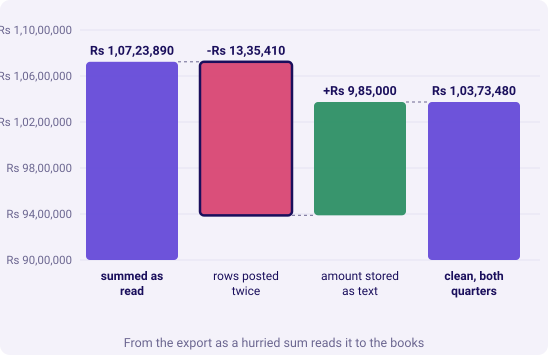

as read Rs 1,07,23,890, duplicates -Rs 13,35,410, text amount +Rs 9,85,000, lands on Rs 1,03,73,480


In [10]:
as_read = sum(int(r["amount"]) for r in rows if r["amount"].isdigit())
dupes = -sum(int(r["amount"]) for r in rejected)
text_back = sum(r["amount"] for r in clean if any(e["order_id"] == r["order_id"] and
                e["decision"] == "convert and flag" for e in log))
kit.bridge(("summed as read", as_read),
           [("rows posted twice", dupes), ("amount stored as text", text_back)],
           end_label="clean, both quarters",
           title="From the export as a hurried sum reads it to the books", lit=[0], lo=9_000_000)
print(f"as read {kit.rupees(as_read)}, duplicates {kit.rupees(dupes)}, text amount +{kit.rupees(text_back)}, "
      f"lands on {kit.rupees(as_read + dupes + text_back)}")

**The third trap, the one most rooms fall into: the reconciliation skipped.** A run that keeps
the repeated rows and loses the text amount compares two wrong quarters and reports growth. Each
half of the mistake on its own gives a different wrong number, and all three are below.

In [11]:
def total(q, keep_dupes, text_ok):
    src = rows if keep_dupes else list({r["order_id"]: r for r in rows}.values())
    out = 0
    for r in src:
        if r["quarter"] != q:
            continue
        v = r["amount"]
        out += int(v.replace(",", "")) if text_ok else (int(v) if v.isdigit() else 0)
    return out


def change(a, b):
    return 100 * (b / a - 1)


variants = [("the reconciled run", False, True), ("duplicates kept, text read correctly", True, True),
            ("duplicates removed, text set to zero", False, False), ("both mistakes, the hurried run", True, False)]
kit.table(["run", "Q1", "Q2", "Q1 to Q2"],
          [(name, kit.rupees(total("Q1", d, t)), kit.rupees(total("Q2", d, t)),
            f"{change(total('Q1', d, t), total('Q2', d, t)):+.1f}%") for name, d, t in variants],
          caption="One export, four headlines")
honest = change(total("Q1", False, True), total("Q2", False, True))
hurried = change(total("Q1", True, False), total("Q2", True, False))
kit.check("the hurried run reports growth where the books show a fall", hurried > 0 > honest,
          f"{hurried:+.1f}% against {honest:+.1f}%")

run,Q1,Q2,Q1 to Q2
the reconciled run,"Rs 60,48,000","Rs 43,25,480",-28.5%
"duplicates kept, text read correctly","Rs 60,48,000","Rs 56,60,890",-6.4%
"duplicates removed, text set to zero","Rs 50,63,000","Rs 43,25,480",-14.6%
"both mistakes, the hurried run","Rs 50,63,000","Rs 56,60,890",+11.8%


## 4. Decompose along the tree, segment by segment

Revenue is customers, times orders per customer, times revenue per order. The total moved; the
tree says which branch, in which segment.

In [12]:
SEGS = ("Retail-Core", "Retail-Plus", "Student", "Business")


def tree(src, q, seg):
    rs = [r for r in src if r["quarter"] == q and r["segment"] == seg]
    cust = len({r["customer_id"] for r in rs})
    rev = sum(int(r["amount"]) for r in rs)
    return len(rs), cust, len(rs) / cust, rev / len(rs), rev


rows_out = []
for seg in SEGS:
    a, b = tree(clean, "Q1", seg), tree(clean, "Q2", seg)
    rows_out.append((seg, f"{a[1]} / {b[1]}", f"{a[2]:.2f} / {b[2]:.2f}",
                     f"{kit.rupees(a[3])} / {kit.rupees(b[3])}", f"{change(a[4], b[4]):+.1f}%", f"{a[0]} / {b[0]}"))
kit.table(["segment", "customers Q1 / Q2", "orders per customer", "revenue per order", "revenue", "orders"],
          rows_out, caption="The tree, clean, Q1 against Q2")

segment,customers Q1 / Q2,orders per customer,revenue per order,revenue,orders
Retail-Core,30 / 30,1.47 / 1.47,"Rs 2,050 / Rs 1,700",-17.1%,44 / 44
Retail-Plus,20 / 20,1.70 / 1.75,"Rs 2,800 / Rs 2,760",+1.5%,34 / 35
Student,12 / 12,1.17 / 1.33,Rs 900 / Rs 880,+11.7%,14 / 16
Business,5 / 4,1.20 / 1.00,"Rs 9,75,000 / Rs 10,35,000",-29.2%,6 / 4


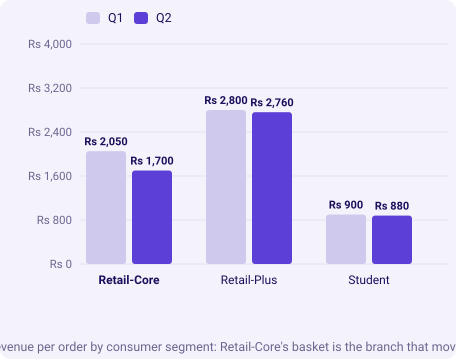

The fall is Rs 17,22,520; Business carries Rs 17,10,000 of it, 99.3 percent, on 6 orders then 4


In [13]:
consumer = SEGS[:3]
kit.columns(list(consumer), [("Q1", [tree(clean, "Q1", s)[3] for s in consumer]),
                             ("Q2", [tree(clean, "Q2", s)[3] for s in consumer])],
            title="Revenue per order by consumer segment: Retail-Core's basket is the branch that moved",
            fmt=lambda v: kit.rupees(v), lit=[0])
biz = tree(clean, "Q1", "Business")[4] - tree(clean, "Q2", "Business")[4]
whole = int(control["Q1"]["amount_rs"]) - int(control["Q2"]["amount_rs"])
print(f"The fall is {kit.rupees(whole)}; Business carries {kit.rupees(biz)} of it, {100 * biz / whole:.1f} percent, "
      f"on {tree(clean, 'Q1', 'Business')[0]} orders then {tree(clean, 'Q2', 'Business')[0]}")

In [14]:
core1, core2 = tree(clean, "Q1", "Retail-Core"), tree(clean, "Q2", "Retail-Core")
kit.check("Retail-Core's customers and frequency hold while its basket falls",
          core1[1] == core2[1] and abs(core1[2] - core2[2]) < 0.01 and change(core1[3], core2[3]) < -15,
          f"{change(core1[3], core2[3]):+.1f}% per order")
kit.check("the corporate fall rests on fewer than thirty orders",
          tree(clean, "Q1", "Business")[0] + tree(clean, "Q2", "Business")[0] < 30)

**The fourth trap: the wrong branch.** On the uncleaned rows Retail-Core's customers seem to
order about a fifth more often in Q2, which cancels the basket fall and reads the segment as
flat. The frequency rise is the repeated batch and nothing else.

In [15]:
h1 = tree([r for r in rows if r["segment"] and r["amount"].isdigit()], "Q1", "Retail-Core")
h2 = tree([r for r in rows if r["segment"] and r["amount"].isdigit()], "Q2", "Retail-Core")
kit.table(["Retail-Core", "orders per customer", "revenue per order", "revenue"],
          [("hurried Q1", f"{h1[2]:.2f}", kit.rupees(h1[3]), kit.rupees(h1[4])),
           ("hurried Q2", f"{h2[2]:.2f}", kit.rupees(h2[3]), kit.rupees(h2[4])),
           ("hurried change", f"{change(h1[2], h2[2]):+.1f}%", f"{change(h1[3], h2[3]):+.1f}%", f"{change(h1[4], h2[4]):+.1f}%"),
           ("clean change", f"{change(core1[2], core2[2]):+.1f}%", f"{change(core1[3], core2[3]):+.1f}%",
            f"{change(core1[4], core2[4]):+.1f}%")],
          caption="The repeated rows turn a basket problem into a flat segment")
kit.check("the hurried run shows frequency up and revenue flat in Retail-Core",
          change(h1[2], h2[2]) > 15 and abs(change(h1[4], h2[4])) < 1)

Retail-Core,orders per customer,revenue per order,revenue
hurried Q1,1.47,"Rs 2,050","Rs 90,200"
hurried Q2,1.77,"Rs 1,702","Rs 90,210"
hurried change,+20.5%,-17.0%,+0.0%
clean change,+0.0%,-17.1%,-17.1%


## 5. One shuffle test, on the customer

Thursday's test, rerun: does Retail-Core's change in revenue per order differ from Retail-Plus's
by more than chance produces? The labels are shuffled across **customers**, because a
customer's orders belong together. 2,000 shuffles, `random.Random(7)`.

observed gap -15.6 points; 39 of 2,000 shuffles as extreme; p = 0.0195


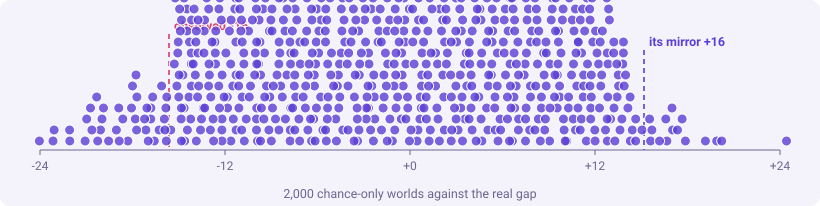

In [16]:
def basket_change(rs):
    a = [r["amount"] for r in rs if r["quarter"] == "Q1"]
    b = [r["amount"] for r in rs if r["quarter"] == "Q2"]
    return change(sum(a) / len(a), sum(b) / len(b))


core = [r for r in clean if r["segment"] == "Retail-Core"]
plus = [r for r in clean if r["segment"] == "Retail-Plus"]
observed = basket_change(core) - basket_change(plus)
by_customer = {}
for r in core + plus:
    by_customer.setdefault(r["customer_id"], []).append(r)
members = sorted(by_customer)
n_core = len({r["customer_id"] for r in core})


def shuffled(rng):
    m = members[:]
    rng.shuffle(m)
    return (basket_change([r for c in m[:n_core] for r in by_customer[c]])
            - basket_change([r for c in m[n_core:] for r in by_customer[c]]))


rng = random.Random(7)
gaps = [shuffled(rng) for _ in range(2000)]
extreme = sum(1 for g in gaps if abs(g) >= abs(observed))
print(f"observed gap {observed:+.1f} points; {extreme} of 2,000 shuffles as extreme; p = {extreme / 2000:.4f}")
kit.strip(gaps, markers=[("observed", observed, "bad"), ("its mirror", -observed, "plain")],
          lo=-24, hi=24, fmt=lambda v: f"{v:+.0f}", title="2,000 chance-only worlds against the real gap")

In [17]:
band = []
for seed in range(1, 21):
    r2 = random.Random(seed)
    band.append(sum(1 for _ in range(2000) if abs(shuffled(r2)) >= abs(observed)) / 2000)
print(f"Twenty other seeds at 2,000 shuffles: p from {min(band):.4f} to {max(band):.4f}")
kit.check("the gap is one chance rarely produces, on every seed tried", max(band) < 0.05,
          f"p = {extreme / 2000:.4f} on seed 7")

Twenty other seeds at 2,000 shuffles: p from 0.0145 to 0.0270


**The fifth trap: the wrong unit.** Shuffling orders instead of customers splits each customer's
orders across the two groups, builds worlds that could not exist, widens the chance spread, and
turns a real gap into "could be chance".

In [18]:
both = core + plus
rng = random.Random(7)
ext_orders = 0
for _ in range(2000):
    idx = list(range(len(both)))
    rng.shuffle(idx)
    a = [both[i] for i in idx[:len(core)]]
    b = [both[i] for i in idx[len(core):]]
    if abs(basket_change(a) - basket_change(b)) >= abs(observed):
        ext_orders += 1
print(f"shuffling orders: {ext_orders} of 2,000, p = {ext_orders / 2000:.4f}")
kit.check("shuffling the wrong unit moves the verdict across 0.05", ext_orders / 2000 > 0.05 > extreme / 2000)

shuffling orders: 151 of 2,000, p = 0.0755


## 6. The note, in four parts, as a correct run writes it

**Claim.** From Q1 to Q2 booked revenue fell 28.5 percent, from Rs 60,48,000 to Rs 43,25,480,
and Rs 17,10,000 of the Rs 17,22,520 fall is two fewer corporate orders; among consumers the
one branch that moved is Retail-Core's revenue per order, down 17.1 percent from Rs 2,050 to
Rs 1,700, with its 30 customers and 1.47 orders each unchanged.

**Evidence.** 197 distinct orders reconcile to Finance's control totals in both quarters, 98
and 99 orders to the rupee, after dropping 10 rows posted twice and converting one amount
stored as text; the Retail-Core gap against Retail-Plus beat 39 of 2,000 customer-level
shuffles, p = 0.02.

**Caveat.** The corporate fall rests on six orders against four, too few to call a trend, and
one Q2 order's segment was restored from the customer's other orders.

**Action.** Open Retail-Core's basket first, items per order and price per item, before any
spend; treat the corporate fall as noise until a third quarter says otherwise.

**The sixth trap: the headline on ten orders.** "Corporate revenue fell 29 percent" is true to
the rupee and rests on ten orders; a note that leads with it sends Meera after two invoices.

In [19]:
kit.table(["trap", "the wrong number", "the right number", "the check that catches it"], [
    ("the typical order", kit.rupees(statistics.mean(amounts_all)) + " (mean)",
     kit.rupees(statistics.median(amounts_all)) + " (median)", "sort, read the top ten"),
    ("the pass that looks clean", "Q1 " + kit.rupees(zeroed_q1) + ", 0 rejects",
     "Q1 " + kit.rupees(int(control["Q1"]["amount_rs"])), "rupees against the control total"),
    ("the reconciliation skipped", f"Q2 {hurried:+.1f}%", f"Q2 {honest:+.1f}%", "input = clean + rejected; control totals"),
    ("the wrong branch", f"Retail-Core frequency {change(h1[2], h2[2]):+.1f}%, revenue flat",
     f"basket {change(core1[3], core2[3]):+.1f}%, frequency flat", "distinct ids against rows, per segment"),
    ("the wrong unit", f"p = {ext_orders / 2000:.4f}", f"p = {extreme / 2000:.4f}", "shuffle customers"),
    ("the headline on ten orders", "corporate revenue -29.2%", "6 orders then 4", "count before rate"),
], caption="Every trap in the lab, with its exact wrong number")

trap,the wrong number,the right number,the check that catches it
the typical order,"Rs 52,057 (mean)","Rs 2,110 (median)","sort, read the top ten"
the pass that looks clean,"Q1 Rs 50,63,000, 0 rejects","Q1 Rs 60,48,000",rupees against the control total
the reconciliation skipped,Q2 +11.8%,Q2 -28.5%,input = clean + rejected; control totals
the wrong branch,"Retail-Core frequency +20.5%, revenue flat","basket -17.1%, frequency flat","distinct ids against rows, per segment"
the wrong unit,p = 0.0755,p = 0.0195,shuffle customers
the headline on ten orders,corporate revenue -29.2%,6 orders then 4,count before rate


## The practice export, for the practice lab

The same method on the practice file, so the TA holds every number a learner reruns toward.
Its defects sit in yet other places.

In [20]:
prac = kit.load_csv("C2_W01_D05_practice_orders_STUDENT.csv")
pctl = {c["quarter"]: c for c in kit.load_csv("C2_W01_D05_practice_control_STUDENT.csv")}
pids = [r["order_id"] for r in prac]
pclean, pseen = [], set()
for r in prac:
    if r["order_id"] in pseen:
        continue
    pseen.add(r["order_id"])
    r = dict(r)
    r["amount"] = int(r["amount"].replace("Rs", "").replace(",", "").strip())
    pclean.append(r)
odd = [r for r in prac if not r["amount"].isdigit()]
blank = [r for r in prac if not r["customer_id"]]
kit.table(["measure", "value"], [
    ("rows", len(prac)), ("distinct order ids", len(set(pids))), ("amounts that will not convert", len(odd)),
    ("rows with no customer_id", len(blank)),
    ("Q1 clean / control", f"{kit.rupees(sum(r['amount'] for r in pclean if r['quarter'] == 'Q1'))} / {kit.rupees(int(pctl['Q1']['amount_rs']))}"),
    ("Q2 clean / control", f"{kit.rupees(sum(r['amount'] for r in pclean if r['quarter'] == 'Q2'))} / {kit.rupees(int(pctl['Q2']['amount_rs']))}"),
], caption="The practice export, reconciled")
ptab = []
for seg in SEGS:
    a = [r for r in pclean if r["quarter"] == "Q1" and r["segment"] == seg]
    b = [r for r in pclean if r["quarter"] == "Q2" and r["segment"] == seg]
    ca = len({r["customer_id"] for r in a if r["customer_id"]})
    cb = len({r["customer_id"] for r in b if r["customer_id"]})
    ptab.append((seg, f"{ca} / {cb}", f"{len(a) / ca:.2f} / {len(b) / cb:.2f}",
                 f"{kit.rupees(sum(r['amount'] for r in a) / len(a))} / {kit.rupees(sum(r['amount'] for r in b) / len(b))}",
                 f"{len(a)} / {len(b)}"))
kit.table(["segment", "customers", "orders per customer", "revenue per order", "orders"], ptab,
          caption="The practice tree, Q1 / Q2 (customers counted on rows that carry an id)")
kit.check("the practice export reconciles to its control totals",
          all(sum(r["amount"] for r in pclean if r["quarter"] == q) == int(pctl[q]["amount_rs"]) and
              sum(1 for r in pclean if r["quarter"] == q) == int(pctl[q]["orders"]) for q in ("Q1", "Q2")))

measure,value
rows,79
distinct order ids,75
amounts that will not convert,1
rows with no customer_id,1
Q1 clean / control,"Rs 23,21,000 / Rs 23,21,000"
Q2 clean / control,"Rs 23,39,340 / Rs 23,39,340"


segment,customers,orders per customer,revenue per order,orders
Retail-Core,12 / 11,1.50 / 1.64,"Rs 2,100 / Rs 2,080",18 / 18
Retail-Plus,8 / 8,2.00 / 1.50,"Rs 2,900 / Rs 2,850",16 / 12
Student,2 / 3,1.00 / 1.00,Rs 900 / Rs 900,2 / 3
Business,3 / 3,1.00 / 1.00,"Rs 7,45,000 / Rs 7,55,000",3 / 3


In [21]:
kit.check_summary()